## **Regresión lineal parte 1**: 

## Ley de zipf


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import string
from collections import Counter
from sklearn import linear_model

Leemos el archivo con el corpus de texto

In [11]:
df = pd.read_csv("https://raw.githubusercontent.com/Jorgeprevi/ML_bootcamp_2026/refs/heads/main/regresion_lineal/textos.csv")
df.head()

,id,text,author
0,id26305,"This process, however, afforded me no means of...",EAP
1,id17569,It never once occurred to me that the fumbling...,HPL
2,id11008,"In his left hand was a gold snuff box, from wh...",EAP
3,id27763,How lovely is spring As we looked from Windsor...,MWS
4,id12958,"Finding nothing else, not even gold, the Super...",HPL


Quitamos los signos de puntuación de la columna de texto

In [12]:
def remove_punctuations(input_col):
    """Función para eliminar los signos de puntuación de una columna de texto"""
    table = str.maketrans('','',string.punctuation)
    return input_col.translate(table)

df['text'] = df['text'].apply(remove_punctuations)

Creamos un string con la unión total del corpus de texto (minúscula)

In [16]:
def build_corpus(text_col):
    """construye un corpus de texto a partir de una columna de texto"""
    corpus = ""
    for sent in text_col:
        corpus += sent
    return corpus

corpus = build_corpus(df['text'])
corpus = corpus.lower()

corpus[:1000]

'this process however afforded me no means of ascertaining the dimensions of my dungeon as i might make its circuit and return to the point whence i set out without being aware of the fact so perfectly uniform seemed the wallit never once occurred to me that the fumbling might be a mere mistakein his left hand was a gold snuff box from which as he capered down the hill cutting all manner of fantastic steps he took snuff incessantly with an air of the greatest possible self satisfactionhow lovely is spring as we looked from windsor terrace on the sixteen fertile counties spread beneath speckled by happy cottages and wealthier towns all looked as in former years heart cheering and fairfinding nothing else not even gold the superintendent abandoned his attempts but a perplexed look occasionally steals over his countenance as he sits thinking at his deska youth passed in solitude my best years spent under your gentle and feminine fosterage has so refined the groundwork of my character that

Creamos una lista con todas las palabras del corpus de texto

In [17]:
corpus = corpus.split()
print(corpus[:50])

['this', 'process', 'however', 'afforded', 'me', 'no', 'means', 'of', 'ascertaining', 'the', 'dimensions', 'of', 'my', 'dungeon', 'as', 'i', 'might', 'make', 'its', 'circuit', 'and', 'return', 'to', 'the', 'point', 'whence', 'i', 'set', 'out', 'without', 'being', 'aware', 'of', 'the', 'fact', 'so', 'perfectly', 'uniform', 'seemed', 'the', 'wallit', 'never', 'once', 'occurred', 'to', 'me', 'that', 'the', 'fumbling', 'might']


In [ ]:
top_n = 15
min_count = 1
fit_max_rank = 5000

# 1) Contar y ordenar
counts = Counter(corpus)
items = sorted(counts.items(), key=lambda x: x[1], reverse=True)
# Filtrado por frecuencia mínima
if min_count > 1:
    items = [(w, c) for (w, c) in items if c >= min_count]
if len(items) < 5:
    raise ValueError("Muy pocos elementos tras el filtrado; reduce min_count o revisa datos.")

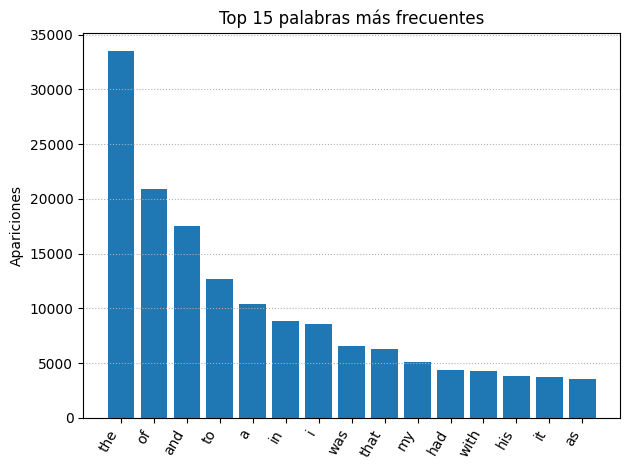

In [21]:
# ---- FIGURA 1: Barplot Top-N ----
top_n = min(top_n, len(items))
top_words = [w for (w, _) in items[:top_n]]
top_counts = [c for (_, c) in items[:top_n]]
plt.figure()
plt.bar(range(top_n), top_counts)
plt.xticks(range(top_n), top_words, rotation=60, ha="right")
plt.ylabel("Apariciones")
plt.title(f"Top {top_n} palabras más frecuentes")
plt.grid(True, axis="y", linestyle=":")
plt.tight_layout()
plt.show()

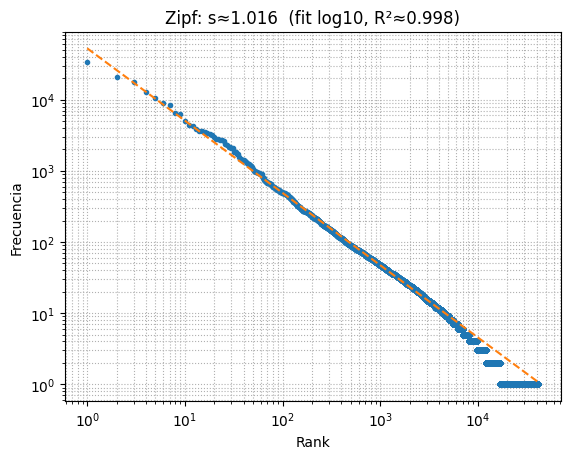

In [ ]:
# ---- FIGURA 2: Zipf ----

# ---- Preparar arrays rank/freq para Zipf ----
freqs = np.array([c for (_, c) in items], dtype=float)
ranks = np.arange(1, len(freqs) + 1, dtype=float)

# Tramo para el fit
if fit_max_rank is not None:
    m = ranks <= float(fit_max_rank)
    r_fit = ranks[m]
    f_fit = freqs[m]
else:
    r_fit = ranks
    f_fit = freqs
x = np.log10(r_fit)
y = np.log10(f_fit)
# OLS en logspace: y = a + b x  => s = -b
b, a = np.polyfit(x, y, 1)
s_hat = -b
C_hat = 10 ** a
# R² en espacio log
y_pred = a + b * x
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan


plt.figure()
plt.loglog(ranks, freqs, marker=".", linestyle="none")
f_model = C_hat * (ranks ** (-s_hat))
plt.loglog(ranks, f_model, linestyle="--")
plt.xlabel("Rank")
plt.ylabel("Frecuencia")
plt.title(f"Zipf: s≈{s_hat:.3f}  (fit log10, R²≈{r2:.3f})")
plt.grid(True, which="both", linestyle=":")
plt.show()

## **Regresión lineal parte 2**: 

## Terremotos en Granada

Leemos el archivo con los datos de terremotos en la zona de Granada desde 2019 hasta hoy

In [ ]:
df_terremotos = pd.read_csv("terremotos_granada.csv", sep = ";")
df_terremotos.head()

,Evento,Fecha,Hora,Latitud,Longitud,Prof,Inten,Mag,TipoMag,Localizacion
0,es2018dpbji,02/04/2018,04:45:59,36.8871,-3.7176,10.0,,1.6,4,NW LENTEGÍ.GR
1,es2018dpeam,02/04/2018,10:05:22,37.1579,-3.6927,12.0,II,2.7,4,W CÚLLAR VEGA.GR
2,es2018dphbk,02/04/2018,16:42:26,37.2332,-3.6958,0.0,,1.3,4,NW ATARFE.GR
3,es2018dpogd,03/04/2018,08:30:23,36.8632,-2.8686,10.0,,1.8,4,N DALÍAS.AL
4,es2018eajhk,04/04/2018,08:32:39,36.8522,-2.9145,16.0,,1.9,4,E BERJA.AL


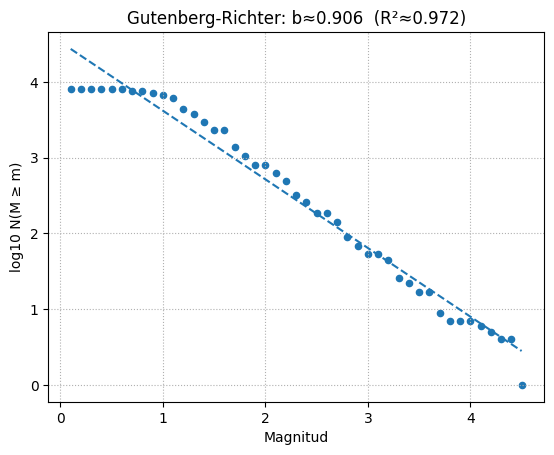

In [ ]:
bin_width = 0.1      # resolución de magnitud
min_count = 5        # mínimo para considerar el punto en el fit

# ---- 1) Limpiar magnitudes ----
mags = df_terremotos["Mag"].dropna().astype(float).values

# ---- 2) Crear bins de magnitud ----
m_min = np.floor(mags.min()*10)/10
m_max = np.ceil(mags.max()*10)/10

bins = np.arange(m_min, m_max + bin_width, bin_width)

# ---- 3) Conteo acumulado N(M >= m) ----
hist, edges = np.histogram(mags, bins=bins)

# acumulado inverso
cum_counts = np.cumsum(hist[::-1])[::-1]

magnitudes = edges[:-1]

# ---- 4) Filtrar tramo útil ----
mask = cum_counts >= min_count
M_fit = magnitudes[mask]
N_fit = cum_counts[mask]

x = M_fit
y = np.log10(N_fit)

# ---- 5) Ajuste lineal ----
b_slope, a_intercept = np.polyfit(x, y, 1)

b_value = -b_slope
a_value = a_intercept

# R²
y_pred = a_intercept + b_slope * x
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - ss_res/ss_tot

# ---- 6) Plot ----
plt.figure()

plt.scatter(magnitudes, np.log10(cum_counts), s=20)

x_model = np.linspace(magnitudes.min(), magnitudes.max(), 200)
y_model = a_intercept + b_slope * x_model

plt.plot(x_model, y_model, linestyle="--")

plt.xlabel("Magnitud")
plt.ylabel("log10 N(M ≥ m)")
plt.title(f"Gutenberg-Richter: b≈{b_value:.3f}  (R²≈{r2:.3f})")

plt.grid(True, linestyle=":")
plt.show()